# HOM Validation: Temporal, Polarization, and Spectral Overlap

This notebook uses the full SeQUeNCe two-source SPDC setup with real fibers, a central HOM/BSM node, and polarization-resolved idler analyzers.

For the clean HOM dip, both sources emit `psi-`. The idlers are measured in the `Z` basis. Matching idler outcomes (`HH` or `VV`) project the two signal photons into matching polarizations before they reach the HOM beam splitter, so the matched-projection fourfold curve should show a deep dip at zero delay when spectral and temporal overlap are also high.

`O_extra` is fixed to 1.0.



In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (8, 4)



## Base configuration




In [5]:
# Plotting configuration. Simulation is run only from run_hom_three_overlap_batch.py.
SOURCE_FREQUENCY_HZ = 8e7
TEMPORAL_SCAN_HALF_RANGE_PS = 800


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for path in [start, *start.parents]:
        if (path / 'sequence').exists() and (path / 'example').exists():
            return path
    # If the notebook is opened from its own folder, walk relative to this file layout.
    candidate = Path.cwd().resolve()
    if candidate.name == 'hom_swapping_validation':
        return candidate.parents[1]
    raise RuntimeError('Could not find SeQUeNCe repository root from current notebook directory.')


REPO_ROOT = find_repo_root()
CONFIG_NAME = 'hom_three_overlap_batch_config'
CONFIG_PATH = REPO_ROOT / 'example' / 'hom_swapping_validation' / 'configs' / f'{CONFIG_NAME}.ini'
RESULTS_DIR = REPO_ROOT / 'example' / 'hom_swapping_validation' / 'results' / CONFIG_NAME


def load_validation_csv(name: str) -> pd.DataFrame:
    path = RESULTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(
            f'Missing {path}. Run example/hom_swapping_validation/run_hom_three_overlap_batch.py first.'
        )
    return pd.read_csv(path)

print('Repository root:', REPO_ROOT)
print('Loading HOM validation CSVs from:', RESULTS_DIR)


def load_run_csv(name: str) -> pd.DataFrame:
    return load_validation_csv(name)


def add_counts_per_s(df: pd.DataFrame, count_cols, duration_col: str = 'duration_per_run_s') -> pd.DataFrame:
    df = df.copy()
    if duration_col in df.columns:
        duration = df[duration_col].astype(float).replace(0, np.nan)
    else:
        duration = pd.Series(1.0, index=df.index)
    for col in count_cols:
        if col in df.columns:
            df[col + '_per_s'] = df[col].astype(float) / duration
    return df


def summarize_run_observable(df: pd.DataFrame, group_cols, value_cols) -> pd.DataFrame:
    agg = {}
    for col in value_cols:
        agg[col + '_mean'] = (col, 'mean')
        agg[col + '_std'] = (col, 'std')
    out = df.groupby(group_cols, sort=True).agg(**agg).reset_index()
    out = out.fillna(0.0)
    return out


def minmax_normalize(y: pd.Series) -> pd.Series:
    y = y.astype(float)
    span = float(y.max() - y.min())
    if span <= 0:
        return pd.Series(np.zeros(len(y)), index=y.index)
    return (y - float(y.min())) / span




Repository root: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-hom
Loading HOM validation CSVs from: c:\Users\ana35\OneDrive - NIST\Desktop\cooding\sequence_simulator\SeQUeNCe-hom\example\hom_swapping_validation\results\hom_three_overlap_batch_config


## 1) Temporal HOM dip (delay scan)

Experimental observable: fourfold BSM coincidence counts/s from detector timestamps, averaged across runs.


In [6]:
scan_half_range_ps = TEMPORAL_SCAN_HALF_RANGE_PS

df_temporal = load_validation_csv('hom_temporal_delay_scan_validation.csv').copy()
df_temporal_runs = load_run_csv('hom_temporal_runs.csv')

temporal_count_cols = [
    'matched_herald_fourfold_count',
    'mismatched_herald_fourfold_count',
    'hom_fourfold_count',
]
df_temporal_runs = add_counts_per_s(df_temporal_runs, temporal_count_cols)
temporal_obs = summarize_run_observable(
    df_temporal_runs,
    ['delay_ps'],
    [c + '_per_s' for c in temporal_count_cols],
)

center_row = temporal_obs.loc[temporal_obs['delay_ps'].abs().idxmin()]
far_mean = temporal_obs.loc[
    temporal_obs['delay_ps'].abs() >= 0.6 * scan_half_range_ps,
    'matched_herald_fourfold_count_per_s_mean',
].mean()
dip_percent = (1 - float(center_row['matched_herald_fourfold_count_per_s_mean']) / max(float(far_mean), 1e-12)) * 100

pd.DataFrame([{
    'data_source': str(RESULTS_DIR),
    'observable': 'timestamp fourfold counts/s, matched HH+VV heralds',
    'runs_per_delay': int(df_temporal['runs'].iloc[0]) if 'runs' in df_temporal.columns else None,
    'center_counts_per_s_mean': float(center_row['matched_herald_fourfold_count_per_s_mean']),
    'center_counts_per_s_std': float(center_row['matched_herald_fourfold_count_per_s_std']),
    'far_counts_per_s_mean': float(far_mean),
    'dip_depth_percent_from_counts': float(dip_percent),
}])



,data_source,observable,runs_per_delay,center_counts_per_s_mean,center_counts_per_s_std,far_counts_per_s_mean,dip_depth_percent_from_counts
0,c:\Users\ana35\OneDrive - NIST\Desktop\cooding...,"timestamp fourfold counts/s, matched HH+VV her...",10,32.8,3.32666,314.1,89.557466


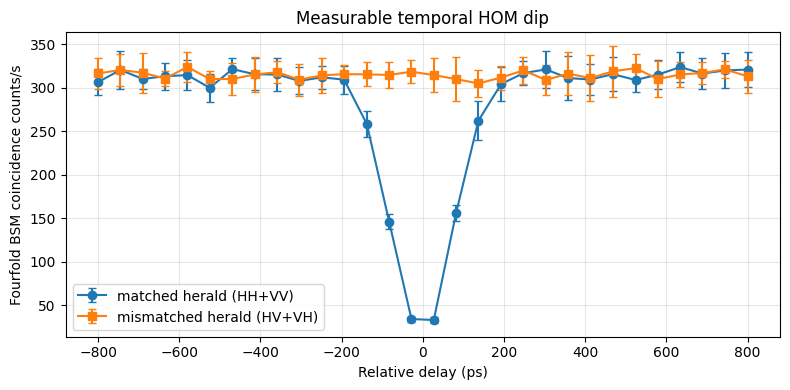

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

x = temporal_obs['delay_ps']
ax.errorbar(
    x,
    temporal_obs['matched_herald_fourfold_count_per_s_mean'],
    yerr=temporal_obs['matched_herald_fourfold_count_per_s_std'],
    marker='o',
    capsize=3,
    label='matched herald (HH+VV)',
)
ax.errorbar(
    x,
    temporal_obs['mismatched_herald_fourfold_count_per_s_mean'],
    yerr=temporal_obs['mismatched_herald_fourfold_count_per_s_std'],
    marker='s',
    capsize=3,
    label='mismatched herald (HV+VH)',
)
ax.set_xlabel('Relative delay (ps)')
ax.set_ylabel('Fourfold BSM coincidence counts/s')
ax.set_title('Measurable temporal HOM dip')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 2) Polarization overlap validation with idler projection

Experimental observable: fourfold BSM coincidence counts/s while rotating a signal-arm waveplate. Since HOM coincidences scale approximately as $1-O_{pol}$ at zero delay, the same-polarization herald branch is compared to $\sin^2(	heta)$ and the orthogonal branch to $\cos^2(	heta)$ after count normalization.


In [8]:
df_pol = load_validation_csv('hom_polarization_scan_validation.csv').copy()
df_pol_runs = load_run_csv('hom_polarization_runs.csv')

pol_count_cols = [
    'matched_herald_fourfold_count',
    'mismatched_herald_fourfold_count',
]
df_pol_runs = add_counts_per_s(df_pol_runs, pol_count_cols)
pol_obs = summarize_run_observable(
    df_pol_runs,
    ['angle_rad', 'angle_deg'],
    [c + '_per_s' for c in pol_count_cols],
)

pol_obs['same_signal_pol_norm_counts'] = minmax_normalize(pol_obs['matched_herald_fourfold_count_per_s_mean'])
pol_obs['orthogonal_signal_pol_norm_counts'] = minmax_normalize(pol_obs['mismatched_herald_fourfold_count_per_s_mean'])
pol_obs['sin2_reference'] = np.sin(pol_obs['angle_rad'])**2
pol_obs['cos2_reference'] = np.cos(pol_obs['angle_rad'])**2

pol_obs.head()



,angle_rad,angle_deg,matched_herald_fourfold_count_per_s_mean,matched_herald_fourfold_count_per_s_std,mismatched_herald_fourfold_count_per_s_mean,mismatched_herald_fourfold_count_per_s_std,same_signal_pol_norm_counts,orthogonal_signal_pol_norm_counts,sin2_reference,cos2_reference
0,0.000000,0.000000,12.1,2.960856,311.7,17.524903,0.000000,0.998652,0.000000,1.000000
1,0.054165,3.103448,14.5,3.100179,310.1,19.098866,0.008000,0.993259,0.002931,0.997069
2,0.108331,6.206897,16.9,4.605552,312.1,12.296793,0.016000,1.000000,0.011690,0.988310
3,0.162496,9.310345,20.9,4.228212,303.9,22.178318,0.029333,0.972363,0.026173,0.973827
4,0.216662,12.413793,27.4,4.273952,303.4,25.781992,0.051000,0.970677,0.046212,0.953788


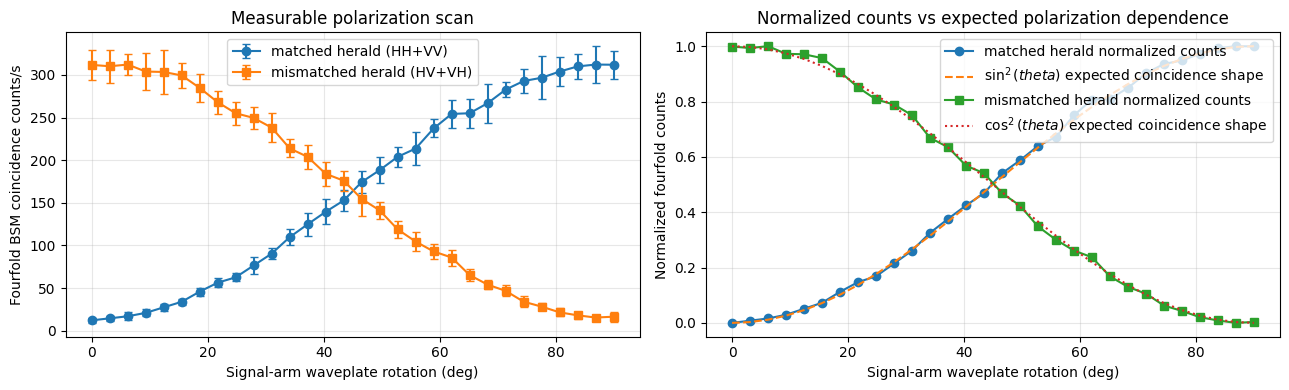

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].errorbar(
    pol_obs['angle_deg'],
    pol_obs['matched_herald_fourfold_count_per_s_mean'],
    yerr=pol_obs['matched_herald_fourfold_count_per_s_std'],
    marker='o',
    capsize=3,
    label='matched herald (HH+VV)',
)
axes[0].errorbar(
    pol_obs['angle_deg'],
    pol_obs['mismatched_herald_fourfold_count_per_s_mean'],
    yerr=pol_obs['mismatched_herald_fourfold_count_per_s_std'],
    marker='s',
    capsize=3,
    label='mismatched herald (HV+VH)',
)
axes[0].set_xlabel('Signal-arm waveplate rotation (deg)')
axes[0].set_ylabel('Fourfold BSM coincidence counts/s')
axes[0].set_title('Measurable polarization scan')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    pol_obs['angle_deg'],
    pol_obs['same_signal_pol_norm_counts'],
    marker='o',
    label='matched herald normalized counts',
)
axes[1].plot(pol_obs['angle_deg'], pol_obs['sin2_reference'], linestyle='--', label=r'$\sin^2(	theta)$ expected coincidence shape')
axes[1].plot(
    pol_obs['angle_deg'],
    pol_obs['orthogonal_signal_pol_norm_counts'],
    marker='s',
    label='mismatched herald normalized counts',
)
axes[1].plot(pol_obs['angle_deg'], pol_obs['cos2_reference'], linestyle=':', label=r'$\cos^2(	theta)$ expected coincidence shape')
axes[1].set_xlabel('Signal-arm waveplate rotation (deg)')
axes[1].set_ylabel('Normalized fourfold counts')
axes[1].set_title('Normalized counts vs expected polarization dependence')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



## 3) Spectral overlap validation (wavelength detuning scan)

Experimental observable: fourfold BSM coincidence counts/s versus wavelength detuning. Larger detuning reduces spectral overlap, so HOM suppression weakens and coincidence counts increase.


In [10]:
df_spec = load_validation_csv('hom_spectral_scan_validation.csv').copy()
df_spec_runs = load_run_csv('hom_spectral_runs.csv')

spec_count_cols = [
    'matched_herald_fourfold_count',
    'mismatched_herald_fourfold_count',
]
df_spec_runs = add_counts_per_s(df_spec_runs, spec_count_cols)
spec_obs = summarize_run_observable(
    df_spec_runs,
    ['detuning_nm'],
    [c + '_per_s' for c in spec_count_cols],
)

spec_obs.head()



,detuning_nm,matched_herald_fourfold_count_per_s_mean,matched_herald_fourfold_count_per_s_std,mismatched_herald_fourfold_count_per_s_mean,mismatched_herald_fourfold_count_per_s_std
0,-0.400000,318.8,14.987402,329.5,16.249786
1,-0.372414,312.5,12.782366,323.6,13.729126
2,-0.344828,316.8,18.641650,310.9,17.527439
3,-0.317241,319.4,10.741405,325.2,21.877436
4,-0.289655,319.2,17.415191,317.8,20.131788


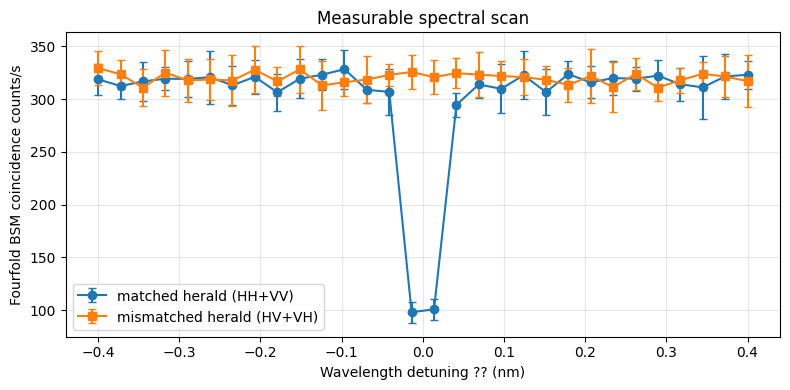

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.errorbar(
    spec_obs['detuning_nm'],
    spec_obs['matched_herald_fourfold_count_per_s_mean'],
    yerr=spec_obs['matched_herald_fourfold_count_per_s_std'],
    marker='o',
    capsize=3,
    label='matched herald (HH+VV)',
)
ax.errorbar(
    spec_obs['detuning_nm'],
    spec_obs['mismatched_herald_fourfold_count_per_s_mean'],
    yerr=spec_obs['mismatched_herald_fourfold_count_per_s_std'],
    marker='s',
    capsize=3,
    label='mismatched herald (HV+VH)',
)
ax.set_xlabel('Wavelength detuning ?? (nm)')
ax.set_ylabel('Fourfold BSM coincidence counts/s')
ax.set_title('Measurable spectral scan')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



## Save outputs




## Data generation

This notebook does not run or save simulation data. Generate CSV inputs with:

```bash
python example/hom_swapping_validation/run_hom_three_overlap_batch.py
```
